#Importaciones de librerías y datos

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate, cross_val_predict
import seaborn as sns
import seaborn.objects as so
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, roc_curve
from sklearn.model_selection import ParameterGrid
import itertools
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import StratifiedKFold
import random
from scipy.stats import uniform
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Ejercicio 1: Separación de datos

Separamos el dataset en un conjunto de desarrollo (90% de las instancias) y control (10% de las instancias). Para hacerlo, tenemos en cuenta que el dataset no está balanceado: menos del 30% de los datos corresponden al target de buen pronóstico '1'.


Por ello, construimos una función que selecciona el 10% de los datos de cada etiqueta utilizando una distribución uniforme, de forma que en el dataset de control se conserva la proporción de etiquetas de datos del conjunto completo.

In [ ]:
!curl -OL 'https://github.com/aprendizaje-automatico-dc-uba-ar/material/raw/refs/heads/main/tp/01_aprendizaje_supervisado/datos/data.csv'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1902k  100 1902k    0     0  2697k      0 --:--:-- --:--:-- --:--:-- 2697k


In [ ]:
df = pd.read_csv('/content/data.csv')
df.head()

,uAro,vIlg,VtZP,qTUs,bgVs,PdRG,CqGH,bfBD,ZtLG,SNCN,...,hnYp,cWwQ,GkqC,VHPu,KKxk,TNkz,GkcC,KSYM,YpTu,target
0,1.284843,0.676813,-0.445511,-0.025185,-4.546595,0.370719,0.104766,-0.365206,1.155584,0.791519,...,2.052021,-0.256875,-0.961930,4.731984,21.095664,-0.738587,0.728201,1.346252,0.659334,1
1,-0.027713,1.020162,-1.665049,-1.052946,3.144244,2.104813,0.603191,0.180639,1.458030,-0.014031,...,0.891111,-1.328636,-0.848692,-3.989681,7.741832,-0.768312,0.160028,-1.028335,-1.733235,1
2,-0.160656,-1.011420,-0.216399,0.797341,5.672563,7.822798,0.806452,0.386419,-0.854304,0.003736,...,1.411142,2.481312,0.492739,-3.132938,-22.681919,-1.066736,-0.041351,-0.311166,-1.299748,0
3,1.128357,0.341273,-1.669474,0.767591,-4.610520,-8.788584,2.272761,-0.762237,-0.245964,-0.101648,...,1.418474,-0.555290,-0.400534,0.149306,-8.262423,-4.142330,1.256389,-1.252168,-1.597531,0
4,0.573025,1.278193,0.112418,-1.431578,0.589556,1.913852,0.021793,0.533563,0.321761,-0.108064,...,-0.487612,-0.818391,-0.158147,-4.996113,-18.901603,-1.276128,0.318565,-0.592519,1.788781,0


In [ ]:
def separa_df(df):

    # Seteo una seed para hacer siempre la misma separación.
    np.random.seed(37)

    # Me guardo por separado los índices de las filas correspondientes
    #a las etiquetas 0 y 1 del DF original.
    idx0 = df.index[df['target'] == 0]
    idx1 = df.index[df['target'] == 1]

    # Calcula la cantidad de instancias de cada tipo de target
    cant0 = len(idx0)
    cant1 = len(idx1)

    # Tomo 10% de esos índices al azar con una uniforme para control,
    #de forma que se preserven las proporciones.
    idx_control0 = np.random.choice(idx0, size = int(0.1 * cant0), replace = False)
    idx_control1 = np.random.choice(idx1, size = int(0.1 * cant1), replace = False)

    # Concateno los índices.
    idx_control = np.concatenate([idx_control0, idx_control1])

    # Construyo el df de train/test eliminando del original
    #los elementos del conjunto de control.
    df_train_test = df.drop(idx_control).reset_index(drop = True)
    df_control = df.loc[idx_control].reset_index(drop = True)

    return([df_train_test, df_control])

Usamos la función para dividir los datos:

In [ ]:
df_train_test, df_control = separa_df(df)
df_train_test.head(3)

,uAro,vIlg,VtZP,qTUs,bgVs,PdRG,CqGH,bfBD,ZtLG,SNCN,...,hnYp,cWwQ,GkqC,VHPu,KKxk,TNkz,GkcC,KSYM,YpTu,target
0,1.284843,0.676813,-0.445511,-0.025185,-4.546595,0.370719,0.104766,-0.365206,1.155584,0.791519,...,2.052021,-0.256875,-0.961930,4.731984,21.095664,-0.738587,0.728201,1.346252,0.659334,1
1,-0.027713,1.020162,-1.665049,-1.052946,3.144244,2.104813,0.603191,0.180639,1.458030,-0.014031,...,0.891111,-1.328636,-0.848692,-3.989681,7.741832,-0.768312,0.160028,-1.028335,-1.733235,1
2,-0.160656,-1.011420,-0.216399,0.797341,5.672563,7.822798,0.806452,0.386419,-0.854304,0.003736,...,1.411142,2.481312,0.492739,-3.132938,-22.681919,-1.066736,-0.041351,-0.311166,-1.299748,0


Acá vemos que la proporción de instancias de cada clase es aproximadamente la misma.

In [ ]:
print(f"Proporción de target 1 en el df original: {sum(df['target']==1)/df.shape[0]:.3}")
print(f"Proporción de target 1 en el df train/test: {sum(df_train_test['target']==1)/df_train_test.shape[0]:.3}")
print(f"Proporción de target 1 en el df control: {sum(df_control['target']==1)/df_control.shape[0]:.3}")

Proporción de target 1 en el df original: 0.294
Proporción de target 1 en el df train/test: 0.295
Proporción de target 1 en el df control: 0.286


# Ejercicio 2: Construcción de modelos

Separamos en features y target

In [ ]:
X = df_train_test.drop('target', axis = 1)
y = df_train_test['target']

##2.1 y 2.2 (version  folds automatico)
Entrenar un árbol de decisión con altura máxima 3 y el resto de los hiperparámetros en default.



In [ ]:
#Árbol con altura máxima 3 y hiperparams default
arbol = DecisionTreeClassifier(max_depth=3, random_state=37)
k = 5

#Usamos cross_val_precict para obtener los scores asignados por el árbol correspondiente a de cada uno de los 5 folds de validación
predictions = cross_val_predict(arbol, X, y, cv=k) #predicciones etiquetas duras: 0 o 1
predictions_proba = cross_val_predict(arbol, X, y, cv=k, method='predict_proba') #probabilidad de pertenecer a cada clase
pred_proba_class_1 = predictions_proba[:, 1] #probabilidad de pertenecer a la clase positiva

# Calculamos global scores para predictions
accuracy_global = accuracy_score(y, predictions)
auc_roc_global = roc_auc_score(y, pred_proba_class_1)
auprc_global = average_precision_score(y, pred_proba_class_1)

#Podemos calcular las métricas globales
scoring = ['average_precision','roc_auc','accuracy'] #Metricas del enunciado

#Hacemos cross_validate para los scores de train y test de los 5 folds
score_results = cross_validate(
    arbol,
    X, y,
    cv=k,
    scoring=scoring,
    return_train_score=True
)


Construimos la tabla

In [ ]:
# Construimos la tabla
decimals = 3
rows = []

#Filas scores train y test
for i in range(k):
    rows.append([
        i+1,  # permutación
        round(score_results['train_accuracy'][i], decimals),
        round(score_results['test_accuracy'][i], decimals),
        round(score_results['train_average_precision'][i], decimals),
        round(score_results['test_average_precision'][i], decimals),
        round(score_results['train_roc_auc'][i], decimals),
        round(score_results['test_roc_auc'][i], decimals)
    ])

# Fila 6: promedios
rows.append([
    "Promedio",
    round(np.mean(score_results['train_accuracy']), decimals),
    round(np.mean(score_results['test_accuracy']), decimals),
    round(np.mean(score_results['train_average_precision']), decimals),
    round(np.mean(score_results['test_average_precision']), decimals),
    round(np.mean(score_results['train_roc_auc']), decimals),
    round(np.mean(score_results['test_roc_auc']), decimals)
])

# Fila 7: score global
rows.append([
    "Global",
    "",  # vacío para training
    round(accuracy_global, decimals),
    "",  # vacío para training
    round(auprc_global, decimals),
    "",  # vacío para training
    round(auc_roc_global, decimals)
])

# Crear tabla
tabla = pd.DataFrame(rows, columns=[
    "Permutación",
    "Accuracy (training)",
    "Accuracy (validación)",
    "AUPRC (training)",
    "AUPRC (validación)",
    "AUC ROC (training)",
    "AUC ROC (validación)"
])

# Mostramos sin índice
display(HTML(tabla.to_html(index=False)))

Permutación,Accuracy (training),Accuracy (validación),AUPRC (training),AUPRC (validación),AUC ROC (training),AUC ROC (validación)
1,0.831,0.670,0.675,0.369,0.809,0.556
2,0.825,0.722,0.678,0.490,0.818,0.744
3,0.817,0.778,0.673,0.567,0.847,0.758
4,0.85,0.744,0.706,0.510,0.847,0.738
5,0.853,0.667,0.729,0.348,0.865,0.614
Promedio,0.835,0.716,0.692,0.457,0.837,0.682
Global,,0.716,,0.472,,0.692


##2.1 y 2.2 (versión folds manuales)
Estimar la performance del modelo utilizando K-fold cross validation con K=5, con las métricas Accuracy, Area Under the Precision-Recall Curve (AUPRC), y Area Under the Receiver Operating Characteristic Curve (AUCROC).

In [ ]:
#FOLDS ESTRATIFICADOS
# Metricas
scoring = ['average_precision','roc_auc','accuracy']

# Listas
ACCU_TEST, ROC_AUC_TEST, AUPRC_TEST = [], [], []
ACCU_TRAIN, ROC_AUC_TRAIN, AUPRC_TRAIN = [], [], []

# Folds estratificados
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

predicciones_global = np.zeros(len(y), dtype=float)

# Loop de cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    modelo = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
    modelo.fit(X_train, y_train)

    # Predicciones TEST
    preds = modelo.predict_proba(X_test)[:, 1]
    predicciones_global[test_idx] = preds

    ACCU_TEST.append(accuracy_score(y_test, modelo.predict(X_test)))
    ROC_AUC_TEST.append(roc_auc_score(y_test, preds))
    AUPRC_TEST.append(average_precision_score(y_test, preds))

    # Predicciones TRAIN
    preds_train = modelo.predict_proba(X_train)[:, 1]
    ACCU_TRAIN.append(accuracy_score(y_train, modelo.predict(X_train)))
    ROC_AUC_TRAIN.append(roc_auc_score(y_train, preds_train))
    AUPRC_TRAIN.append(average_precision_score(y_train, preds_train))

# Global
accuracy_global = accuracy_score(y, np.round(predicciones_global))
roc_auc_global = roc_auc_score(y, predicciones_global)
avg_precision_global = average_precision_score(y, predicciones_global)


In [ ]:
# Columnas de la tabla
columnas = [
    "Permutación",
    "Accuracy (training)",
    "Accuracy (validación)",
    "AUPRC (training)",
    "AUPRC (validación)",
    "AUC ROC (training)",
    "AUC ROC (validación)"
]

# Crear DataFrame vacío
tabla = pd.DataFrame(columns=columnas)

# --- Agregar resultados fold a fold ---
for i in range(len(ACCU_TEST)):
    tabla.loc[len(tabla)] = [
        i+1,
        ACCU_TRAIN[i],
        ACCU_TEST[i],
        AUPRC_TRAIN[i],
        AUPRC_TEST[i],
        ROC_AUC_TRAIN[i],
        ROC_AUC_TEST[i]
    ]

# --- Fila de promedios de los folds ---
Mean_train_acc    = np.mean(ACCU_TRAIN)
Mean_test_acc     = np.mean(ACCU_TEST)
Mean_train_auprc  = np.mean(AUPRC_TRAIN)
Mean_test_auprc   = np.mean(AUPRC_TEST)
Mean_train_rocauc = np.mean(ROC_AUC_TRAIN)
Mean_test_rocauc  = np.mean(ROC_AUC_TEST)

tabla.loc[len(tabla)] = [
    "Promedios",
    Mean_train_acc,
    Mean_test_acc,
    Mean_train_auprc,
    Mean_test_auprc,
    Mean_train_rocauc,
    Mean_test_rocauc
]

# --- Fila Global usando valores out-of-fold ---
tabla.loc[len(tabla)] = [
    "Global",
    np.nan,  # dejamos en blanco training con NaN
    accuracy_global,
    np.nan,
    avg_precision_global,
    np.nan,
    roc_auc_global
]

# Redondear a 3 decimales (todas las columnas numéricas)
tabla = tabla.round(3)

tabla

,Permutación,Accuracy (training),Accuracy (validación),AUPRC (training),AUPRC (validación),AUC ROC (training),AUC ROC (validación)
0,1.0,0.831,0.714,0.732,0.450,0.863,0.682
1,2.0,0.845,0.733,0.681,0.486,0.834,0.745
2,3.0,0.850,0.622,0.744,0.380,0.855,0.617
3,4.0,0.823,0.778,0.691,0.600,0.822,0.828
4,5.0,0.828,0.756,0.698,0.574,0.818,0.758
5,Promedios,0.835,0.721,0.709,0.498,0.838,0.726
6,Global,NaN,0.721,NaN,0.486,NaN,0.722


##2.3
Explorar las siguientes combinaciones de parámetros para árboles de decisión (siguiendo con
 con
) utilizando ParameterGrid de scikit learn. No está permitido utilizar GridSearchCV en este ejercicio

In [ ]:
#Armo el grid con los parametros que pide el enunciado
param_grid = {
    'max_depth': [3, 5, None],
        'criterion': ["gini", "entropy"]
}
scoring = ['accuracy'] #Metricas del enunciado
resultados = []

# Generás todas las combinaciones
for params in ParameterGrid(param_grid):
    arbol = DecisionTreeClassifier(
        **params,  # desempaqueta criterion y max_depth
        random_state=37
    )

    #scores = cross_validate(arbol, X, y, scoring=scoring,cv=5)

    #Hacemos cross_validate para los scores de train y test de los 5 folds
    scores = cross_validate(
      arbol,
      X, y,
      cv=k,
      scoring=scoring,
      return_train_score=True
    )

    #Guardar métricas promedio de una vez

    fila = {
        **params,  # agrega criterion y max_depth
        'train_accuracy': scores['train_accuracy'].mean(),
        'test_accuracy': scores['test_accuracy'].mean(),
    }
    resultados.append(fila)

#Para poder trabajar con la claves mas facil, convierto a data frame
df_resultados = pd.DataFrame(resultados).round(3)

# 1. Renombrar columnas
df_resultados = df_resultados.rename(columns={
    'criterion': 'Criterio de corte',
    'max_depth': 'Altura máxima',
    'train_accuracy': 'Accuracy (training)',
    'test_accuracy': 'Accuracy (validación)'
})

# 2. Reemplazar NaN por la palabra "Infinito"
df_resultados = df_resultados.replace({np.nan: "Infinito"})

# 3. Quitar el índice al mostrar la tabla
from IPython.display import display, HTML
display(HTML(df_resultados.to_html(index=False)))


Criterio de corte,Altura máxima,Accuracy (training),Accuracy (validación)
gini,3.0,0.835,0.716
gini,5.0,0.933,0.687
gini,Infinito,1.000,0.672
entropy,3.0,0.808,0.705
entropy,5.0,0.914,0.685
entropy,Infinito,1.000,0.679


En los resultados puede verse que al aumentar la altura del árbol mejora el accuracy en el conjunto de train pero baja en el de test. En el caso extremo con altura infinita el train accuracy es 1, es decir, ajusta perfectamente los datos de entrenamiento. Sin embargo, en el conjunto de testeo el score es el más bajo. Esto muestra que a medida que aumenta la altura el modelo overfitea.

# Ejercicio 3: Comparación de algoritmos

## 3.1. Árbol

Elegimos los hiperparámetros para explorar y definimos la búsqueda. Usamos 200 iteraciones.

In [ ]:
# Hiperparámetros a explorar (mínimo 4):
param_dist = {
    'max_depth': np.arange(2, 10), #maxima profundidad del arbol
    'min_samples_split': np.arange(2, 50), #minima cantidad de instancias para dividir un nodo
    'min_weight_fraction_leaf': uniform(loc=0, scale=0.5), #minima cantidad de instancias para poder ser una hoja
    'criterion': ['gini', 'entropy', 'log_loss']
}

#Definimos RandomizedSearch
random_search_arbol = RandomizedSearchCV(
    estimator = DecisionTreeClassifier(),
    param_distributions = param_dist,
    n_iter = 200,                # cantidad de iteraciones
    scoring= 'roc_auc',        # metrica
    cv= 5,                     # 5 folds stratified cross-val
    verbose= 1,
    random_state= 42,
)

Aca fuimos probando en hiperparametros y los valores maximos de arange. Pasamos del min_samples_leaf al min_weight_fraction_leaf y obtuvimos una mejoria en el accuracy.

Vimos que cambiar la cantidad de iteraciones mejora bastante la accuracy pero se estanca cerca de 200. Entiendo que tiene que ver con que ya evaluas la mayoria de posibles combinaciones posibles de hiperparametros

Hacemos la búsqueda

In [ ]:
random_search_arbol.fit(X, y)
print("Best Parameters:", random_search_arbol.best_params_)
print("Best Cross-Validation AUCROC:", random_search_arbol.best_score_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': np.int64(4), 'min_samples_split': np.int64(18), 'min_weight_fraction_leaf': np.float64(0.06700761422532037)}
Best Cross-Validation AUCROC: 0.7093712197010809


## 3.1. KNN

Elegimos los hiperparámetros para explorar y definimos la búsqueda. Usamos 50 iteraciones.

In [ ]:
# Hiperparámetros a explorar (mínimo 3):
param_dist = {
    'n_neighbors': np.arange(2, 50), #numero de vecinos considerados
    'weights': ['uniform', 'distance'], #peso de los vecinos
    'p': [1,2,3], # métrica de distancia
}

#Búsqueda
random_search_knn = RandomizedSearchCV(
    estimator = KNeighborsClassifier(),
    param_distributions = param_dist,
    n_iter = 50,                # cantidad de iteraciones
    scoring= 'roc_auc',        # metrica
    cv= 5,                     # 5 folds stratified cross-val
    verbose= 1,
    random_state= 42,
)


Analogo al anterior, probamos el p y weights porq los de kernel no mejoraban demasiado. Lo del kernel parece que funciona para distribuciones muy especificas. Con 50 iteraciones parece ser suficiente para un buen valor de AUCROC.

Hacemos la búsqueda

In [ ]:
random_search_knn.fit(X, y)
print("Best Parameters:", random_search_knn.best_params_)
print("Best Cross-Validation AUCROC:", random_search_knn.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': np.int64(14)}
Best Cross-Validation AUCROC: 0.8692355034368923


## 3.1. SVM

Elegimos los hiperparámetros para explorar y definimos la búsqueda. Usamos 50 iteraciones.

In [ ]:
#Hiperparámetros a explorar
param_dist = {
    'C': uniform(0,100), # regularization hyperparameter
    'class_weight': [None,'balanced'] #pesos de las clases
}

#Búsqueda
random_search_svm = RandomizedSearchCV(
    estimator = SVC(probability=True),
    param_distributions = param_dist,
    n_iter = 50,                # cantidad de iteraciones
    scoring= 'roc_auc',        # metrica
    cv= 5,                     # 5 folds stratified cross-val
    verbose= 1,
    random_state= 42,
)

Con 50 iteraciones parece ser más que suficiente. Probamos usar escala logarítmica para la exploración del parámetro C pero no vimos una diferencia notable en el score resultante.

Hacemos la búsqueda

In [ ]:
random_search_svm.fit(X, y)
print("Best Parameters:", random_search_svm.best_params_)
print("Best Cross-Validation AUCROC:", random_search_svm.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'C': np.float64(5.8083612168199465), 'class_weight': 'balanced'}
Best Cross-Validation AUCROC: 0.8969230486591597


## 3.2. LDA (Linear discriminant analysis)

In [ ]:
LDA = LinearDiscriminantAnalysis()

scores = cross_val_score(LDA, X, y, cv=5, scoring= 'roc_auc')

print('Score (ROC_AUC) per fold', scores)
print("Mean score:", np.mean(scores), 'STD:', np.std(scores) )

Score (ROC_AUC) per fold [0.69212963 0.71193416 0.76366843 0.65865385 0.61598558]
Mean score: 0.6884743278840502 STD: 0.049722747256697175


## 3.2. Naive Bayes

Hay varios tipos, usaremos el de Gauss

In [ ]:
G_NB = GaussianNB()

scores = cross_val_score(G_NB, X, y, cv= 5, scoring= 'roc_auc')

print('Score (ROC_AUC) per fold', scores)
print("Mean score:", np.mean(scores), 'STD:', np.std(scores))

Score (ROC_AUC) per fold [0.76736111 0.8377425  0.8154027  0.72175481 0.78064904]
Mean score: 0.7845820331931442 STD: 0.04008799904189787


Un hiperparametro que puede ser importante en ambos algoritmos son las priors, o sea, las prioridades de cada clase. En nuestro caso el dataset esta desbalanceado (30% clase positiva y 70% negativa). Ambos algoritmos por default estiman las priors como la proporcion de clases. Esto hace que la probabilidad calculada favorezca mas a la clase mayoritaria (en este caso negativa), pudiendo generar que clasifiquen mas instancias negativas de las que hay. En otras palabras, puede generar que haya varios FN.

Para LDA otro parámetro que podría ser importante es shrinkage, el cual aplica un factor de encogimiento a la matriz de covarianza que quizás sea útil para el caso de un dataset donde el número de muestras es chico en comparación con la cantidad de atributos.




```
# Tiene formato de código
```

## 3.3. ¿Cuál fue el mejor modelo y con qué configuración?
Explicar por qué creería que dio mejor (recordando qué hace cada algoritmo y con qué tipo de datos están trabajando).

Vemos que SVM es el algoritmo que nos dio mayor AUCROC.
Esperábamos que SVM funcione bien por no hacer asunciones tan fuertes de la distribución de los datos y, además, porque este algoritmo NO SE ALTERA por los datos lejanos al margen. Esto hace que sea más robusto al variar los datos de entrenamiento y que se vea menos afectado que los otros algoritmos al cambiar el conjunto de entrenamiento por el de testeo.

Además SVM es capaz de capturar fronteras complejas no lineales y en espacios de alta dimensionalidad gracias al truco del kernel, que le permite encontrar un hiperplano de separación en espacios de altas dimensiones sin el costo computacional de tener que hacer cálculos explícitos en ese espacio. En el caso de este dataset que contiene una gran cantidad de columnas, creemos que esta característica es clave.
Por otra parte, el modelo puede manejar bien el overfitting regulando el parámetro C.

Naive-Bayes: esperábamos que este modelo no tenga una buena performance debido a que asume una distribución normal de los datos e independencia entre los atributos, lo cual en este contexto creemos que no tiene sentido. Sin embargo, en la bibliografía leímos que funciona bien para datasets con poca cantidad de datos en comparación a la cantidad de atributos, el cual sería nuestro caso.

LDA: asume normalidad y genera fronteras lineales, cuando en este caso suponemos que las fronteras de los datos son más complejas dada la alta dimensionalidad del dataset. Por estas razones entendemos que haya tenido un mal desempeño.

Árboles de decisión: notamos que cambia bastante la performance con el parámetro de max_depth, lo cual nos hace pensar que tiende a sobreajustar.

KNN: este modelo nos dio el segundo mejor score. Puede haber dado un score más bajo que SVM por el desbalance de clases, que puede generar (como NB o LDA) falsos negativos. Además al ser muchos atributos y estos contribuir por igual a la distancia, esto podría complejizar la elección de los vecinos.

# Ejercicio 4: Estimacion del AUCROC

Importamos el dataset X_held_out

In [ ]:
!curl -OL 'https://raw.githubusercontent.com/aprendizaje-automatico-dc-uba-ar/material/refs/heads/main/tp/01_aprendizaje_supervisado/datos/X_held_out.csv'


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1902k  100 1902k    0     0  8839k      0 --:--:-- --:--:-- --:--:-- 8807k


In [ ]:
X_held_out = pd.read_csv('/content/X_held_out.csv',sep=',',engine="python")

Como veremos que el AUCROC da sorprendentemente alto, queremos ver cuánta desviación había respecto a la media en el AUCROC de los folds de validación. Entonces, repetimos esto:

In [ ]:
#Árbol con altura máxima 3 y hiperparams default
svm = random_search_svm.best_estimator_#SVC(**random_search.best_params_)
k = 5

#Usamos cross_val_precict para obtener los scores asignados por el árbol correspondiente a de cada uno de los 5 folds de validación
predictions = cross_val_predict(svm, X, y, cv=k) #predicciones etiquetas duras: 0 o 1
predictions_proba = cross_val_predict(svm, X, y, cv=k, method='predict_proba') #probabilidad de pertenecer a cada clase
pred_proba_class_1 = predictions_proba[:, 1] #probabilidad de pertenecer a la clase positiva

# Calculamos global scores para predictions
accuracy_global = accuracy_score(y, predictions)
auc_roc_global = roc_auc_score(y, pred_proba_class_1)
auprc_global = average_precision_score(y, pred_proba_class_1)

#Podemos calcular las métricas globales
scoring = ['average_precision','roc_auc','accuracy'] #Metricas del enunciado

#Hacemos cross_validate para los scores de train y test de los 5 folds
score_results = cross_validate(
    svm,
    X, y,
    cv=k,
    scoring=scoring,
    return_train_score=True
)

In [ ]:
# Construimos la tabla
decimals = 3
rows = []

#Filas scores train y test
for i in range(k):
    rows.append([
        i+1,  # permutación
        round(score_results['train_accuracy'][i], decimals),
        round(score_results['test_accuracy'][i], decimals),
        round(score_results['train_average_precision'][i], decimals),
        round(score_results['test_average_precision'][i], decimals),
        round(score_results['train_roc_auc'][i], decimals),
        round(score_results['test_roc_auc'][i], decimals)
    ])

# Fila 6: promedios
rows.append([
    "Promedio",
    round(np.mean(score_results['train_accuracy']), decimals),
    round(np.mean(score_results['test_accuracy']), decimals),
    round(np.mean(score_results['train_average_precision']), decimals),
    round(np.mean(score_results['test_average_precision']), decimals),
    round(np.mean(score_results['train_roc_auc']), decimals),
    round(np.mean(score_results['test_roc_auc']), decimals)
])

# Fila 7: score global
rows.append([
    "Global",
    "",  # vacío para training
    round(accuracy_global, decimals),
    "",  # vacío para training
    round(auprc_global, decimals),
    "",  # vacío para training
    round(auc_roc_global, decimals)
])

# Crear tabla
tabla = pd.DataFrame(rows, columns=[
    "Permutación",
    "Accuracy (training)",
    "Accuracy (validación)",
    "AUPRC (training)",
    "AUPRC (validación)",
    "AUC ROC (training)",
    "AUC ROC (validación)"
])

# Mostramos sin índice
display(HTML(tabla.to_html(index=False)))

Permutación,Accuracy (training),Accuracy (validación),AUPRC (training),AUPRC (validación),AUC ROC (training),AUC ROC (validación)
1,1.0,0.780,1.0,0.666,1.0,0.856
2,0.997,0.833,1.0,0.819,1.0,0.905
3,1.0,0.878,1.0,0.900,1.0,0.928
4,1.0,0.822,1.0,0.783,1.0,0.889
5,1.0,0.889,1.0,0.856,1.0,0.906
Promedio,0.999,0.840,1.0,0.805,1.0,0.897
Global,,0.840,,0.785,,0.895


Calculamos los scores que asigna nuestro mejor modelo a cada instancia de X_held_out

In [ ]:
X_control = df_control.drop('target', axis = 1)
y_control = df_control['target']

In [ ]:
svm_final = random_search_svm.best_estimator_

probabilidades_best_estimator_held_out = np.round(svm_final.predict_proba(X_held_out)[:,1],4)
probabilidades_best_estimator_control = svm_final.predict_proba(X_control)[:,1]

df_probas_held_out = pd.DataFrame({"output": probabilidades_best_estimator_held_out})

# Exportar a CSV
df_probas_held_out.to_csv("output.csv", index=False)

Usamos el dataset de control para estimar AUCROC de forma realista

Ploteamos las curva ROC y calculamos AUCROC de los modelos árbol, KNN y SVM (para mostrar que en los tres casos el score da más alto que en validación de la etapa de desarrollo)

AUCROC para el arbol con parámetros óptimos: 0.72551
AUCROC para el knn con parámetros óptimos: 0.95510
AUCROC para el svm con parámetros óptimos: 0.97755


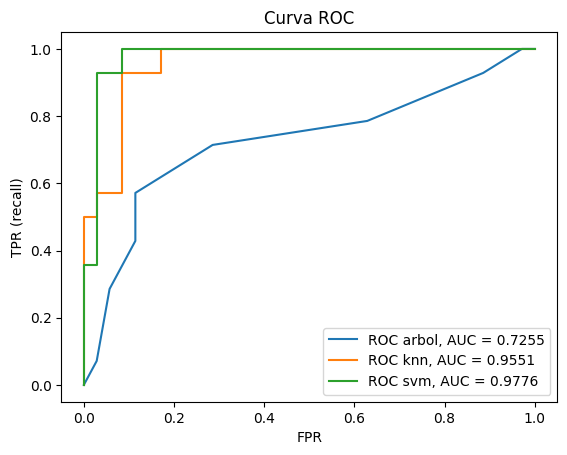

In [ ]:
modelos = [random_search_arbol.best_estimator_, random_search_knn.best_estimator_, random_search_svm.best_estimator_, LDA, G_NB]
nombres = ['arbol','knn','svm']

plt.figure()

for i, modelo in zip([0,1,2],modelos):
  probabilidades_best_estimator_held_out = modelo.predict_proba(X_held_out)[:,1]
  probabilidades_best_estimator_control = modelo.predict_proba(X_control)[:,1]
  probabilidades_best_estimator_train = modelo.predict_proba(X)[:,1]
  fpr, tpr, thresholds = roc_curve(y_control, probabilidades_best_estimator_control)
  plt.plot(fpr, tpr, label=f"ROC {nombres[i]}, AUC = {roc_auc_score(y_control, probabilidades_best_estimator_control):.4f}")
  plt.xlabel("FPR")
  plt.ylabel("TPR (recall)")
  plt.title("Curva ROC")
  plt.legend(loc=4)
  close_zero = np.argmin(np.abs(thresholds))
  plt.legend(loc=4)
  auc = roc_auc_score(y_control, probabilidades_best_estimator_control)
  print(f"AUCROC para el {nombres[i]} con parámetros óptimos: {auc:.5f}")

plt.savefig("rocs.jpg")